In [1]:
pip install numpy pandas pyarrow scikit-learn matplotlib seaborn ipython

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 4.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.2 MB 3.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 3.4 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 3.5 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.2 MB 3.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 3.6 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 3.6 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
# ==========================================
# CONFIGURATION
# ==========================================
DATASET_DIR  = '../dataset'   # folder containing all .parquet files
OUTPUT_DIR   = '.'            # folder to save output CSV files

TRAIN_RATIO  = 0.70           # 70% for training
VAL_RATIO    = 0.15           # 15% for validation
# TEST_RATIO = 0.15           # 15% for testing (remainder)

RANDOM_STATE = 42

**LOAD DATASET** | Unified DDoS Dataset (CIC-DDoS2019)

In [4]:
# --- SCAN AND LOAD ALL PARQUET FILES ---

# Find all parquet files inside the dataset folder
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*.parquet')))
print(f'Found {len(files)} parquet files:\n')

frames = []

for f in files:
    df_part = pd.read_parquet(f, engine='pyarrow')
    name    = os.path.basename(f)
    rows    = len(df_part)
    labels  = df_part['Label'].unique().tolist()

    print(f'  {name:<38s}  {rows:>7,} rows  |  labels: {labels}')
    frames.append(df_part)

Found 17 parquet files:

  DNS-testing.parquet                       6,703 rows  |  labels: ['DrDoS_DNS', 'Benign']
  LDAP-testing.parquet                      2,831 rows  |  labels: ['DrDoS_LDAP', 'Benign']
  LDAP-training.parquet                     6,715 rows  |  labels: ['NetBIOS', 'LDAP', 'Benign']
  MSSQL-testing.parquet                     8,083 rows  |  labels: ['DrDoS_MSSQL', 'Benign']
  MSSQL-training.parquet                   10,974 rows  |  labels: ['MSSQL', 'LDAP', 'Benign']
  NTP-testing.parquet                     134,674 rows  |  labels: ['DrDoS_NTP', 'Benign']
  NetBIOS-testing.parquet                   2,225 rows  |  labels: ['DrDoS_NetBIOS', 'Benign']
  NetBIOS-training.parquet                  1,631 rows  |  labels: ['NetBIOS', 'Benign']
  Portmap-training.parquet                  5,105 rows  |  labels: ['Portmap', 'Benign']
  SNMP-testing.parquet                      4,018 rows  |  labels: ['DrDoS_SNMP', 'Benign']
  Syn-testing.parquet                         907 r

In [5]:
# --- MERGE ALL FILES INTO ONE DATAFRAME ---

df = pd.concat(frames, ignore_index=True)

print(f'Total rows after merging all files : {len(df):,}')
print(f'Total columns                      : {df.shape[1]}')

# Preview first 5 rows to verify data loaded correctly
print('\nData Preview:')
display(df.head())

# General info: data types, null counts, memory usage
print('\nDataset Info:')
df.info()

Total rows after merging all files : 431,371
Total columns                      : 78

Data Preview:


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431371 entries, 0 to 431370
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  431371 non-null  int8   
 1   Flow Duration             431371 non-null  int32  
 2   Total Fwd Packets         431371 non-null  int32  
 3   Total Backward Packets    431371 non-null  int16  
 4   Fwd Packets Length Total  431371 non-null  float32
 5   Bwd Packets Length Total  431371 non-null  float32
 6   Fwd Packet Length Max     431371 non-null  float32
 7   Fwd Packet Length Min     431371 non-null  float32
 8   Fwd Packet Length Mean    431371 non-null  float32
 9   Fwd Packet Length Std     431371 non-null  float32
 10  Bwd Packet Length Max     431371 non-null  float32
 11  Bwd Packet Length Min     431371 non-null  float32
 12  Bwd Packet Length Mean    431371 non-null  float32
 13  Bwd Packet Length Std     431

**CLEANING DATA** | Unified DDoS Dataset

In [6]:
# --- CHECK MISSING VALUES (NaN / Null) ---

print('Number of missing values per column:')
print(df.isnull().sum())

Number of missing values per column:
Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64


In [7]:
# --- REMOVE MISSING VALUES AND DUPLICATES ---

rows_before = len(df)

# Remove rows with any missing value
df = df.dropna()

# Remove exact duplicate rows
df = df.drop_duplicates()

rows_after = len(df)
print(f'Removed  : {rows_before - rows_after:,} rows (NaN + duplicates)')
print(f'Remaining: {rows_after:,} rows')

Removed  : 5,295 rows (NaN + duplicates)
Remaining: 426,076 rows


In [8]:
# --- DROP IRRELEVANT / IDENTITY COLUMNS ---

# These columns cause data leakage or are not useful model features
cols_to_drop = ['Flow ID', 'Source IP', 'Source Port',
                'Destination IP', 'Destination Port', 'Timestamp']

# Only drop columns that actually exist in this dataset
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print(f'Columns dropped  : {existing_cols_to_drop}')
print(f'Remaining columns: {df.shape[1]}')

Columns dropped  : []
Remaining columns: 78


**EXPLORATORY DATA ANALYSIS (EDA)** | Unified DDoS Dataset

In [9]:
# --- LABEL DISTRIBUTION (ALL ATTACK TYPES) ---

label_counts = df['Label'].value_counts()
total = len(df)

print('Label distribution across all files:')
print(f"{'Label':<22s}  {'Count':>8s}  {'Percentage':>10s}")
print('-' * 46)
for label, count in label_counts.items():
    print(f'{str(label):<22s}  {count:>8,}  {count/total*100:>9.1f}%')
print('-' * 46)
print(f"{'TOTAL':<22s}  {total:>8,}  {'100.0%':>10s}")

Label distribution across all files:
Label                      Count  Percentage
----------------------------------------------
DrDoS_NTP                121,368       28.5%
TFTP                      98,917       23.2%
Benign                    94,704       22.2%
Syn                       47,779       11.2%
UDP                       17,795        4.2%
DrDoS_UDP                 10,420        2.4%
UDP-lag                    8,872        2.1%
MSSQL                      8,434        2.0%
DrDoS_MSSQL                6,212        1.5%
DrDoS_DNS                  3,669        0.9%
DrDoS_SNMP                 2,717        0.6%
LDAP                       1,885        0.4%
DrDoS_LDAP                 1,440        0.3%
Portmap                      685        0.2%
DrDoS_NetBIOS                598        0.1%
NetBIOS                      475        0.1%
UDPLag                        55        0.0%
WebDDoS                       51        0.0%
----------------------------------------------
TOTAL         

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_31904\2498426909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


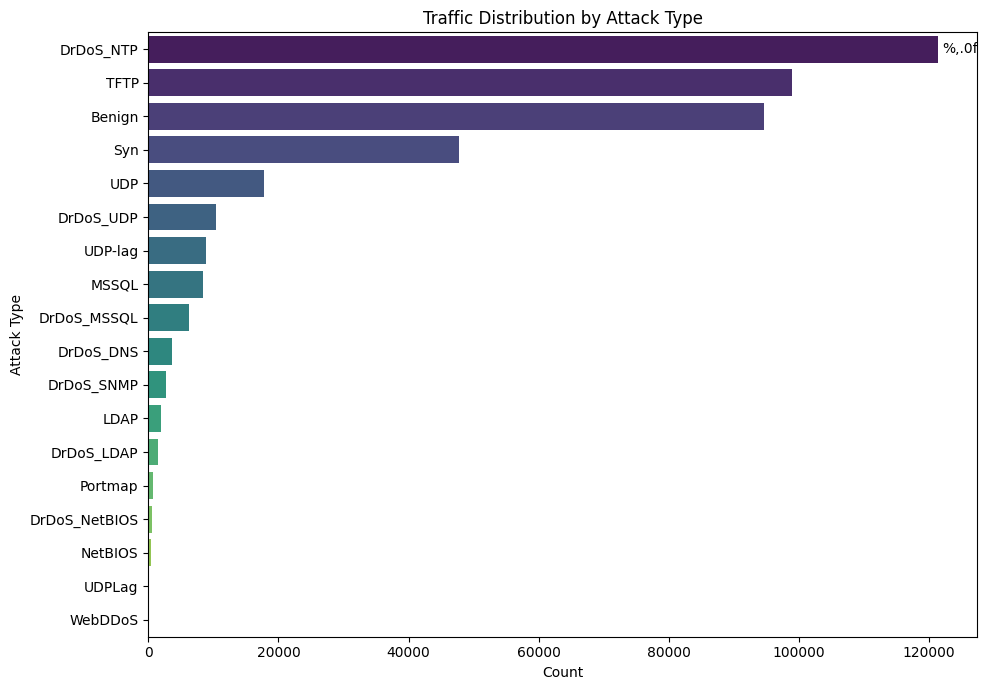

In [10]:
# --- VISUALIZE ATTACK TYPE DISTRIBUTION ---

plt.figure(figsize=(10, 7))
ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
ax.bar_label(ax.containers[0], fmt='%,.0f', padding=3)
ax.set(title='Traffic Distribution by Attack Type', xlabel='Count', ylabel='Attack Type')
plt.tight_layout()
plt.show()

In [11]:
# --- CLASS IMBALANCE CHECK (Benign vs DDoS) ---
# Shows how balanced the data is between normal and attack traffic

benign_count = (df['Label'] == 'Benign').sum()
ddos_count   = total - benign_count

print('Class Distribution (Binary view):')
print(f'  Benign (Safe Traffic) : {benign_count:>8,}  ({benign_count/total*100:.1f}%)')
print(f'  DDoS   (Any Attack)   : {ddos_count:>8,}  ({ddos_count/total*100:.1f}%)')
print(f'\n  Imbalance ratio: 1 : {ddos_count/benign_count:.2f}  (Benign : DDoS)')

Class Distribution (Binary view):
  Benign (Safe Traffic) :   94,704  (22.2%)
  DDoS   (Any Attack)   :  331,372  (77.8%)

  Imbalance ratio: 1 : 3.50  (Benign : DDoS)


**DATA PREPROCESSING** | Unified DDoS Dataset

In [12]:
# --- NORMALIZE DATA (StandardScaler) ---
# StandardScaler transforms each feature to mean=0 and std=1
# This prevents features with large value ranges from dominating the model

scaler = StandardScaler()

# Before normalization
print('Data before normalization:')
display(df.head())

# Apply normalization only to numeric columns (skip the Label column)
X_numeric = df.select_dtypes(include=['number']).columns.drop('Label', errors='ignore')
df[X_numeric] = scaler.fit_transform(df[X_numeric])

# After normalization
print('Data after normalization:')
display(df.head())

Data before normalization:


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS


Data after normalization:


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.604039,-0.398055,-0.113723,-0.043939,-0.190142,-0.01544,3.473708,4.298909,4.266958,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,DrDoS_DNS
1,0.604039,-0.398058,-0.113723,-0.043939,-0.190142,-0.01544,3.473708,4.298909,4.266958,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,DrDoS_DNS
2,0.604039,-0.398058,-0.113723,-0.043939,-0.190142,-0.01544,3.473708,4.298909,4.266958,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,DrDoS_DNS
3,0.604039,-0.398058,-0.113723,-0.043939,-0.190142,-0.01544,3.473708,4.298909,4.266958,-0.286204,...,0.149987,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,DrDoS_DNS
4,0.604039,-0.398058,-0.113723,-0.043939,-0.191527,-0.01544,3.398658,4.211044,4.177421,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,DrDoS_DNS


Before binary encoding:
Label
DrDoS_NTP        121368
TFTP              98917
Benign            94704
Syn               47779
UDP               17795
DrDoS_UDP         10420
UDP-lag            8872
MSSQL              8434
DrDoS_MSSQL        6212
DrDoS_DNS          3669
DrDoS_SNMP         2717
LDAP               1885
DrDoS_LDAP         1440
Portmap             685
DrDoS_NetBIOS       598
NetBIOS             475
UDPLag               55
WebDDoS              51
Name: count, dtype: int64

After binary encoding:
Label
0     94704
1    331372
Name: count, dtype: int64

  Label 0 = Benign (normal traffic)
  Label 1 = DDoS   (any attack type)


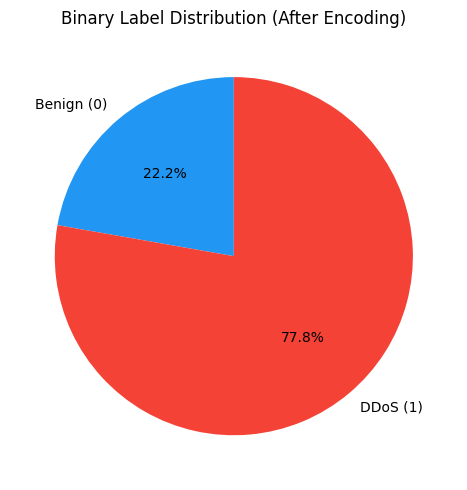

In [13]:
# --- BINARY LABEL ENCODING ---
# 0 = Benign  (safe / normal traffic)
# 1 = DDoS    (any type of attack)
#
# We use a direct mapping instead of LabelEncoder to guarantee
# that Benign always becomes 0 and every attack becomes 1,
# regardless of alphabetical ordering.

print('Before binary encoding:')
print(df['Label'].value_counts())

# Direct binary mapping: Benign -> 0, everything else -> 1
df['Label'] = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1)

print('\nAfter binary encoding:')
counts = df['Label'].value_counts().sort_index()
print(counts)
print('\n  Label 0 = Benign (normal traffic)')
print('  Label 1 = DDoS   (any attack type)')

# Visualize final binary distribution
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    counts.values,
    labels=['Benign (0)', 'DDoS (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2196F3', '#F44336']
)
ax.set_title('Binary Label Distribution (After Encoding)')
plt.tight_layout()
plt.show()

In [14]:
df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.604039,-0.398055,-0.113723,-0.043939,-0.190142,-0.015440,3.473708,4.298909,4.266958,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,1
1,0.604039,-0.398058,-0.113723,-0.043939,-0.190142,-0.015440,3.473708,4.298909,4.266958,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,1
2,0.604039,-0.398058,-0.113723,-0.043939,-0.190142,-0.015440,3.473708,4.298909,4.266958,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,1
3,0.604039,-0.398058,-0.113723,-0.043939,-0.190142,-0.015440,3.473708,4.298909,4.266958,-0.286204,...,0.149987,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,1
4,0.604039,-0.398058,-0.113723,-0.043939,-0.191527,-0.015440,3.398658,4.211044,4.177421,-0.286204,...,0.149977,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431366,-1.629013,-0.398055,-0.118797,-0.008678,-0.275105,-0.015440,-1.129340,-1.090160,-1.224632,-0.286204,...,0.149978,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,0
431367,-1.629013,-0.398055,-0.118797,-0.008678,-0.275105,-0.015440,-1.129340,-1.090160,-1.224632,-0.286204,...,0.149978,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,0
431368,0.604039,-0.396828,-0.113723,-0.008678,-0.272335,-0.014543,-0.979241,-0.914430,-1.045558,-0.286204,...,0.149978,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,0
431369,-1.629013,-0.396623,-0.118797,-0.026309,-0.275105,-0.015440,-1.129340,-1.090160,-1.224632,-0.286204,...,0.149978,-0.10524,-0.115865,-0.131175,-0.066384,-0.31167,-0.250157,-0.330728,-0.277017,0


**TRAIN / VAL / TEST SPLIT** | Unified DDoS Dataset

In [15]:
# --- STRATIFIED TRAIN / VAL / TEST SPLIT ---
# Stratified split preserves the Benign/DDoS class ratio in every subset.
#
# Train : 70%  |  Val : 15%  |  Test : 15%

X = df.drop(columns=['Label'])
y = df['Label']

# Step 1: Split train (70%) vs the remainder (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size   = TRAIN_RATIO,
    stratify     = y,
    random_state = RANDOM_STATE
)

# Step 2: Split the remainder equally into val (15%) and test (15%)
val_ratio_adjusted = VAL_RATIO / (1.0 - TRAIN_RATIO)   # 0.15 / 0.30 = 0.50
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    train_size   = val_ratio_adjusted,
    stratify     = y_temp,
    random_state = RANDOM_STATE
)

print(f"{'Split':<14s}  {'Total':>8s}  {'Benign (0)':>10s}  {'DDoS (1)':>10s}")
print('-' * 48)
for name, (X_s, y_s) in [('Train (70%)', (X_train, y_train)),
                           ('Val   (15%)', (X_val,   y_val)),
                           ('Test  (15%)', (X_test,  y_test))]:
    b = (y_s == 0).sum()
    d = (y_s == 1).sum()
    print(f'{name:<14s}  {len(X_s):>8,}  {b:>10,}  {d:>10,}')

Split              Total  Benign (0)    DDoS (1)
------------------------------------------------
Train (70%)      298,253      66,293     231,960
Val   (15%)       63,911      14,205      49,706
Test  (15%)       63,912      14,206      49,706


In [16]:
# --- EXPORT TO CSV ---
# Each split is saved as a separate CSV file, ready for model training

splits = {
    'unified_train': (X_train, y_train),
    'unified_val'  : (X_val,   y_val),
    'unified_test' : (X_test,  y_test),
}

for filename, (X_s, y_s) in splits.items():
    df_out = X_s.copy()
    df_out['Label'] = y_s.values
    path = os.path.join(OUTPUT_DIR, f'{filename}.csv')
    df_out.to_csv(path, index=False)
    print(f'Saved: {filename}.csv  ({len(df_out):,} rows)')

print('\nDone! All 3 dataset splits saved successfully.')

Saved: unified_train.csv  (298,253 rows)
Saved: unified_val.csv  (63,911 rows)
Saved: unified_test.csv  (63,912 rows)

Done! All 3 dataset splits saved successfully.


In [17]:
# --- FINAL SUMMARY ---

attack_types = label_counts[label_counts.index != 'Benign'].index.tolist()

print('=' * 52)
print('  UNIFIED DATASET SUMMARY')
print('=' * 52)
print(f'  Total rows (after cleaning) : {len(df):,}')
print(f'  Number of features          : {df.shape[1] - 1}')
print(f'  Attack types merged         : {len(attack_types)}')
for a in attack_types:
    print(f'    - {a}')
print(f'')
print(f'  Output files:')
print(f'    unified_train.csv : {len(X_train):,} rows  (70%)')
print(f'    unified_val.csv   : {len(X_val):,} rows  (15%)')
print(f'    unified_test.csv  : {len(X_test):,} rows  (15%)')
print('=' * 52)

  UNIFIED DATASET SUMMARY
  Total rows (after cleaning) : 426,076
  Number of features          : 77
  Attack types merged         : 17
    - DrDoS_NTP
    - TFTP
    - Syn
    - UDP
    - DrDoS_UDP
    - UDP-lag
    - MSSQL
    - DrDoS_MSSQL
    - DrDoS_DNS
    - DrDoS_SNMP
    - LDAP
    - DrDoS_LDAP
    - Portmap
    - DrDoS_NetBIOS
    - NetBIOS
    - UDPLag
    - WebDDoS

  Output files:
    unified_train.csv : 298,253 rows  (70%)
    unified_val.csv   : 63,911 rows  (15%)
    unified_test.csv  : 63,912 rows  (15%)
